<a href="https://colab.research.google.com/github/yejinPARK48/michigan_building_detection/blob/main/05_evaluation/phase5_final_evaluation_cc_dhc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 5: Final Evaluation — Census DHC Comparison & Results

Uses the best model checkpoint from Phase 4.

## Structure
| Section | Description |
|---------|-------------|
| **0. Setup** | Install, import, load Phase 4 best model |
| **5-1. Inference** | Run best model on all 7,462 tiles |
| **5-2. Aggregation** | Sum tile-level counts → block group level |
| **5-3. ACS Comparison** | Compare predicted counts vs. Census DHC housing units |
| **5-4. Visualizations** | Scatter plot, per-county breakdown |
| **5-5. Experiment Log** | Save final results |

## 0. Installation

In [ ]:
import importlib
if importlib.util.find_spec('segmentation_models_pytorch') is None:
    !pip install segmentation-models-pytorch albumentations -q
if importlib.util.find_spec('cv2') is None:
    !pip install opencv-python-headless scikit-image -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.8 MB/s eta 0:00:00


## 0-1. Import

In [ ]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from skimage import measure

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

from google.colab import drive
drive.mount('/content/drive')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Mounted at /content/drive
Device: cuda


## 0-2. Paths & Config

In [ ]:
import subprocess, os

BASE_DIR      = '/content/drive/MyDrive/michigan_unet_project'
META_DIR      = f'{BASE_DIR}/metadata'
CURATED_DIR   = f'{BASE_DIR}/curated'
CKPT_DIR      = f'{BASE_DIR}/checkpoints'
OUT_DIR       = f'{BASE_DIR}/results_phase5_dhc'
os.makedirs(OUT_DIR, exist_ok=True)

# ── Copy tiles to local SSD ───────────────────────────────────────────────
TILE_IMG_DIR  = '/content/fast_tiles/images'
TILE_MASK_DIR = '/content/fast_tiles/masks'
os.makedirs(TILE_IMG_DIR,  exist_ok=True)
os.makedirs(TILE_MASK_DIR, exist_ok=True)

print("Copying tiles to local SSD... (5~10 min)")
subprocess.run(['rsync', '-a', '--ignore-existing',
                f'{BASE_DIR}/tiles/images/',  f'{TILE_IMG_DIR}/'])
subprocess.run(['rsync', '-a', '--ignore-existing',
                f'{BASE_DIR}/tiles/masks/',   f'{TILE_MASK_DIR}/'])
print("Done!")

BEST_THRESHOLD = 0.5    # <- update from Phase 4-1
BEST_MIN_AREA  = 50     # <- update from Phase 4-1
BEST_CKPT      = f'{CKPT_DIR}/unet_seg_best_full_curated.pt'  # Seg-only (CC) model

print(f'Threshold : {BEST_THRESHOLD}')
print(f'Min area  : {BEST_MIN_AREA} px')
print(f'Checkpoint: {os.path.exists(BEST_CKPT)} — {BEST_CKPT}')


Copying tiles to local SSD... (5~10 min)
Done!
Threshold : 0.5
Min area  : 50 px
Checkpoint: True — /content/drive/MyDrive/michigan_unet_project/checkpoints/unet_seg_best_full_curated.pt


## 0-3. Load Model & Data

In [ ]:
# ── Model definition (Seg-Only, CC-based count) ──────────────────────────
model = smp.Unet(encoder_name='resnet34', encoder_weights=None,
                 in_channels=3, classes=1, activation=None).to(DEVICE)
model.load_state_dict(torch.load(BEST_CKPT, map_location=DEVICE))
model.eval()
print('Model loaded.')

# ── Metadata ──────────────────────────────────────────────────────────────
df_meta = pd.read_csv(f'{META_DIR}/tile_metadata.csv',
                      dtype={'geoid': str, 'tract_id': str})
df_meta['footprint_count']     = df_meta['footprint_count'].fillna(0).astype(float)
df_meta['mask_building_ratio'] = df_meta['mask_building_ratio'].fillna(0).astype(float)
print(f'Total tiles in metadata: {len(df_meta)}')

# ── All 7,462 curated tiles for inference ────────────────────────────────
all_tile_ids = pd.read_csv(f'{CURATED_DIR}/tile_stats_clean.csv')['tile_id'].astype(str).tolist()
print(f'Tiles for inference: {len(all_tile_ids)}')

# ── Augmentation (val only) ───────────────────────────────────────────────
val_aug = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])


class InferenceDataset(Dataset):
    def __init__(self, tile_ids, img_dir, transform=None):
        self.tile_ids  = tile_ids
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self): return len(self.tile_ids)

    def __getitem__(self, idx):
        tid = self.tile_ids[idx]
        img = np.array(Image.open(f'{self.img_dir}/{tid}.png').convert('RGB'))
        if self.transform:
            img = self.transform(image=img)['image']
        return img, tid


inf_ds = InferenceDataset(all_tile_ids, TILE_IMG_DIR, val_aug)
inf_ld = DataLoader(inf_ds, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
print(f'Inference loader ready: {len(inf_ds)} tiles')

Model loaded.
Total tiles in metadata: 8308
Tiles for inference: 7462
Inference loader ready: 7462 tiles


---
# Phase 5-1: Inference on All Tiles

Run the best model on all 7,462 curated tiles.
For each tile, predict:
- **CC count**: connected components from predicted mask (with min area filter)
- **MT count**: direct count head output

In [ ]:
# lookup dict
meta_idx  = df_meta.set_index('tile_id')
gt_map    = meta_idx['footprint_count'].to_dict()
geoid_map = meta_idx['geoid'].to_dict()

results = []
model.eval()
with torch.no_grad():
    for imgs, tids in inf_ld:
        imgs = imgs.to(DEVICE)
        seg_logits = model(imgs)
        pred_masks = (torch.sigmoid(seg_logits) > BEST_THRESHOLD).cpu().numpy()

        for b in range(len(tids)):
            tid     = tids[b]
            labeled = measure.label(pred_masks[b, 0])
            cc_cnt  = sum(1 for r in measure.regionprops(labeled) if r.area >= BEST_MIN_AREA)
            results.append({
                'tile_id'  : tid,
                'geoid'    : geoid_map.get(tid),
                'cc_count' : cc_cnt,
                'gt_count' : gt_map.get(tid, 0.0)
            })

df_results = pd.DataFrame(results)
df_results.to_csv(f'{OUT_DIR}/tile_predictions.csv', index=False)
print(f'Inference complete: {len(df_results)} tiles')
print(df_results[['tile_id', 'geoid', 'cc_count', 'gt_count']].head(10).to_string(index=False))

Inference complete: 7462 tiles
           tile_id        geoid  cc_count  gt_count
 260130001001_1004 260130001001         0       0.0
260130001001_10087 260130001001         0       0.0
 260130001001_1069 260130001001         0       0.0
 260130001001_1150 260130001001         0       0.0
260130001001_12422 260130001001         0       0.0
260130001001_12423 260130001001         0       0.0
260130001001_12427 260130001001         0       0.0
260130001001_12568 260130001001         0       0.0
260130001001_12629 260130001001         0       0.0
260130001001_12994 260130001001         0       0.0


---
# Phase 5-2: Aggregation to Block Group Level

Sum tile-level predictions → block group level:

```
tile_predictions.csv [tile_id + geoid + predicted count]
        ↓
groupby geoid → sum(count)
        ↓
block group-level predicted building count
```

In [ ]:
# ── Aggregate to block group ─────────────────────────────────────────────
bg_preds = df_results.groupby('geoid').agg(
    pred_cc_count  = ('cc_count', 'sum'),
    gt_fp_count    = ('gt_count', 'sum'),
    n_tiles        = ('tile_id',  'count'),
).reset_index()

print(f'Block groups: {len(bg_preds)}')
print(bg_preds.head(10).to_string(index=False))

# ── Load ACS housing unit data ────────────────────────────────────────────
# Update path to your ACS file
ACS_PATH = f'{BASE_DIR}/census_dhc_michigan_bg_2020.csv'  # 2020 Census DHC

if os.path.exists(ACS_PATH):
    df_acs = pd.read_csv(ACS_PATH, dtype={'geoid': str})
    # Expected columns: geoid, acs_housing_units
    df_eval = bg_preds.merge(df_acs[['geoid', 'acs_housing_units']], on='geoid', how='inner')
    print(f'\nMatched block groups (preds + ACS): {len(df_eval)}')
else:
    print(f'ACS file not found at {ACS_PATH} — update ACS_PATH above.')
    df_eval = bg_preds.copy()
    df_eval['acs_housing_units'] = np.nan

df_eval.to_csv(f'{OUT_DIR}/block_group_predictions.csv', index=False)
print(df_eval.head(5).to_string(index=False))

Block groups: 1267
       geoid  pred_cc_count  gt_fp_count  n_tiles
260130001001              4          9.0       26
260130001002              0          0.0       10
260130001003              0          0.0        2
260130001004             28         29.0        1
260130002001             19         14.0       21
260130002002             14          8.0        5
260130002003              7          4.0       14
260130002004              6          6.0      133
260139901000              0          0.0        3
260350001001             59         43.0       71

Matched block groups (preds + ACS): 1267
       geoid  pred_cc_count  gt_fp_count  n_tiles  acs_housing_units
260130001001              4          9.0       26                826
260130001002              0          0.0       10                910
260130001003              0          0.0        2                493
260130001004             28         29.0        1                519
260130002001             19         14.0    

---
# Phase 5-3: ACS Comparison

Compare block group-level predicted building counts against ACS housing units.
Metrics: **MAE** and **Pearson correlation**.

In [ ]:
df_valid = df_eval.dropna(subset=['acs_housing_units'])

dhc  = df_valid['acs_housing_units'].values  # Census DHC
cc   = df_valid['pred_cc_count'].values
gt   = df_valid['gt_fp_count'].values

mae_cc  = np.abs(cc - dhc).mean()
mae_gt  = np.abs(gt - dhc).mean()
corr_cc = np.corrcoef(cc, dhc)[0, 1]
corr_gt = np.corrcoef(gt, dhc)[0, 1]

print('=' * 62)
print(f'  {"Method":<22} | {"MAE":>8} | {"Pearson r":>10}')
print('=' * 62)
print(f'  {"CC (seg-only)":<22} | {mae_cc:>8.2f} | {corr_cc:>10.4f}')
print(f'  {"MS Footprints (ref)":<22} | {mae_gt:>8.2f} | {corr_gt:>10.4f}')
print('=' * 62)
print(f'\nCC (seg-only) MAE vs DHC : {mae_cc:.2f} | r={corr_cc:.4f}')
print(f'MS Footprints MAE vs DHC : {mae_gt:.2f} | r={corr_gt:.4f}')


  Method                 |      MAE |  Pearson r
  CC (seg-only)          |   513.84 |     0.1559
  MS Footprints (ref)    |   512.80 |     0.1072

CC (seg-only) MAE vs DHC : 513.84 | r=0.1559
MS Footprints MAE vs DHC : 512.80 | r=0.1072


---
# Phase 5-4: Visualizations

## 5-4-1. Scatter Plot — Predicted vs Census DHC

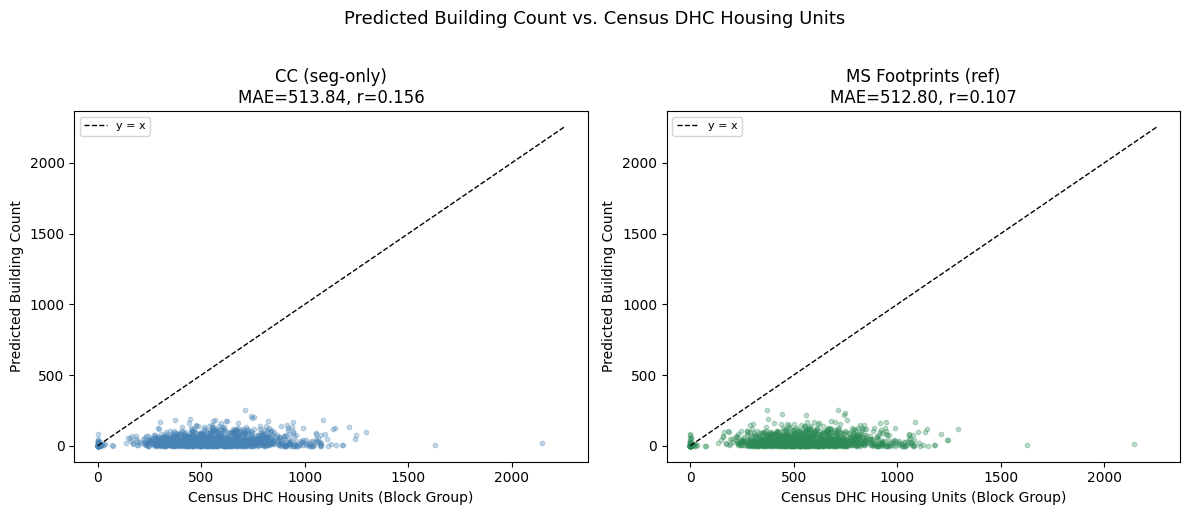

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, label, color, mae, corr in [
    (axes[0], cc, f'CC (seg-only)\nMAE={mae_cc:.2f}, r={corr_cc:.3f}',       'steelblue', mae_cc, corr_cc),
    (axes[1], gt, f'MS Footprints (ref)\nMAE={mae_gt:.2f}, r={corr_gt:.3f}', 'seagreen',  mae_gt, corr_gt),
]:
    ax.scatter(dhc, pred, alpha=0.3, s=10, color=color)
    lim = max(dhc.max(), pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='y = x')
    ax.set_xlabel('Census DHC Housing Units (Block Group)')
    ax.set_ylabel('Predicted Building Count')
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle('Predicted Building Count vs. Census DHC Housing Units', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/phase5_scatter_vs_dhc.png', dpi=150, bbox_inches='tight')
plt.show()


## 5-4-2. Per-County Breakdown

[Per-County Summary]
   county  n_block_groups     mae_cc  corr_cc
  Genesee           244.0 465.098361 0.157011
    Huron            16.0 483.250000 0.086579
 Isabella            43.0 485.627907 0.236550
  Sanilac            19.0 496.578947 0.058142
    Wayne           388.0 496.953608 0.246410
  Tuscola            30.0 510.966667 0.147113
  Oakland           241.0 511.796680 0.086396
  Gogebic             9.0 539.222222 0.186933
    Other           129.0 548.596899 0.396114
   Baraga             9.0 552.666667 0.024866
 Houghton            18.0 563.000000 0.264988
   Ottawa            95.0 625.421053 0.047028
Marquette            10.0 647.500000 0.254094
Ontonagon             4.0 654.000000 0.459088
     Iron            12.0 730.916667 0.612424


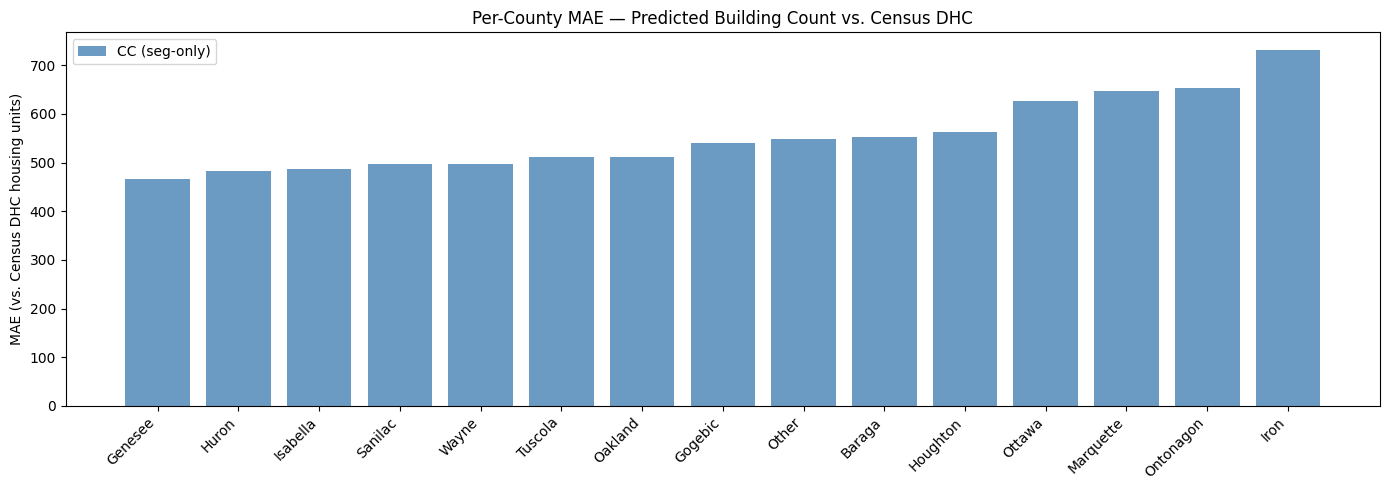

In [ ]:
df_valid2 = df_valid.copy()
df_valid2['county_fips'] = df_valid2['geoid'].str[:5]

county_names = {
    '26163': 'Wayne',      '26125': 'Oakland',    '26049': 'Genesee',
    '26139': 'Ottawa',     '26155': 'Shiawassee', '26073': 'Isabella',
    '26117': 'Montcalm',   '26103': 'Marquette',  '26085': 'Lake',
    '26131': 'Ontonagon',  '26053': 'Gogebic',    '26061': 'Houghton',
    '26071': 'Iron',       '26013': 'Baraga',     '26157': 'Tuscola',
    '26151': 'Sanilac',    '26063': 'Huron',      '26051': 'Gladwin',
    '26059': 'Hillsdale',
}
df_valid2['county'] = df_valid2['county_fips'].map(county_names).fillna('Other')

county_summary = df_valid2.groupby('county').apply(lambda g: pd.Series({
    'n_block_groups': len(g),
    'mae_cc':  np.abs(g['pred_cc_count'] - g['acs_housing_units']).mean(),
    'corr_cc': np.corrcoef(g['pred_cc_count'], g['acs_housing_units'])[0, 1]
               if len(g) > 1 else np.nan,
})).reset_index().sort_values('mae_cc')

print('[Per-County Summary]')
print(county_summary.to_string(index=False))
county_summary.to_csv(f'{OUT_DIR}/phase5_county_breakdown.csv', index=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(county_summary))
ax.bar(x, county_summary['mae_cc'], color='steelblue', alpha=0.8, label='CC (seg-only)')
ax.set_xticks(x); ax.set_xticklabels(county_summary['county'], rotation=45, ha='right')
ax.set_ylabel('MAE (vs. Census DHC housing units)')
ax.set_title('Per-County MAE — Predicted Building Count vs. Census DHC')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/phase5_county_mae.png', dpi=150)
plt.show()


## 5-4-3. Residual Distribution

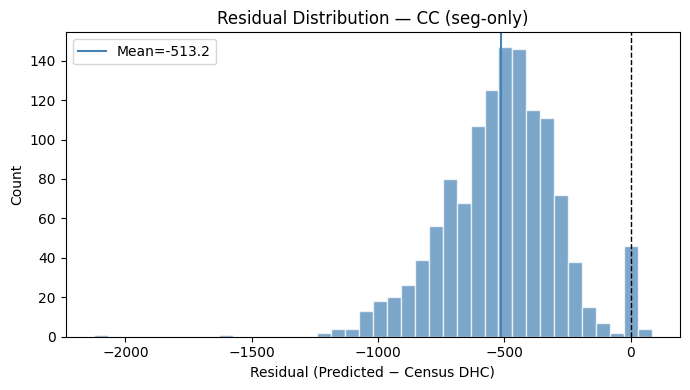

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

residuals = cc - dhc
ax.hist(residuals, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(residuals.mean(), color='steelblue', linestyle='-', linewidth=1.5,
           label=f'Mean={residuals.mean():.1f}')
ax.set_xlabel('Residual (Predicted − Census DHC)')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution — CC (seg-only)')
ax.legend()

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/phase5_residuals.png', dpi=150)
plt.show()


## 5-4-4. Block Group Inspector

Select a block group by GEOID (or use best/worst by MAE) to visualize tile-level results.

=== WORST block group ===
Block Group : 261390245011
Tiles       : 1
GT Footprints (sum) : 10
Pred CC count (sum) : 19
DHC housing units   : 2145
CC error vs DHC     : 2126.0


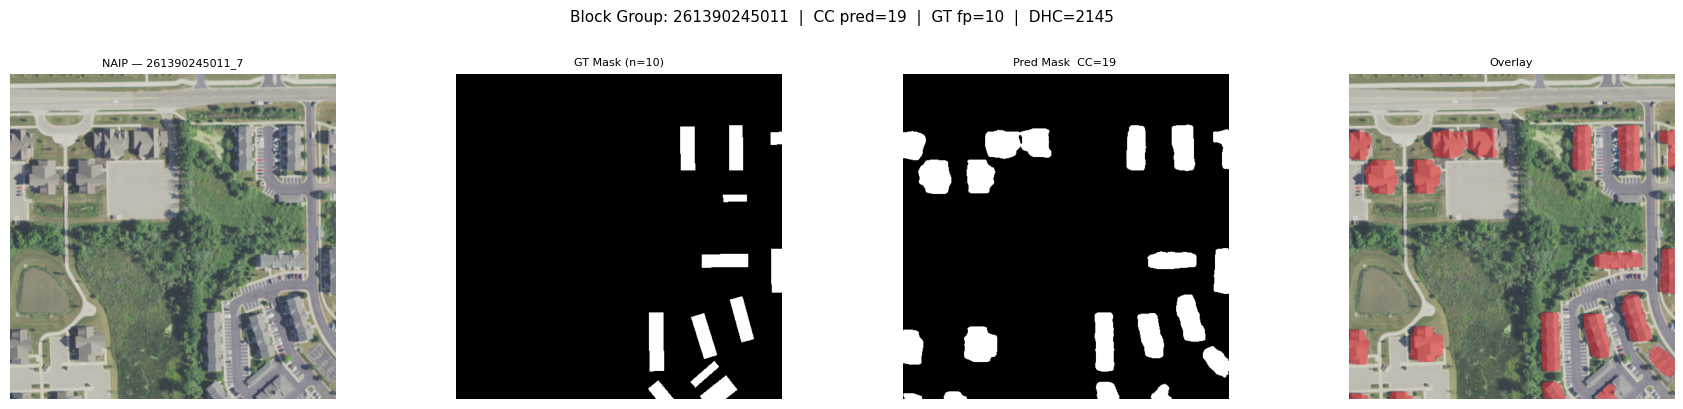


=== BEST block group ===
Block Group : 261639865021
Tiles       : 2
GT Footprints (sum) : 0
Pred CC count (sum) : 0


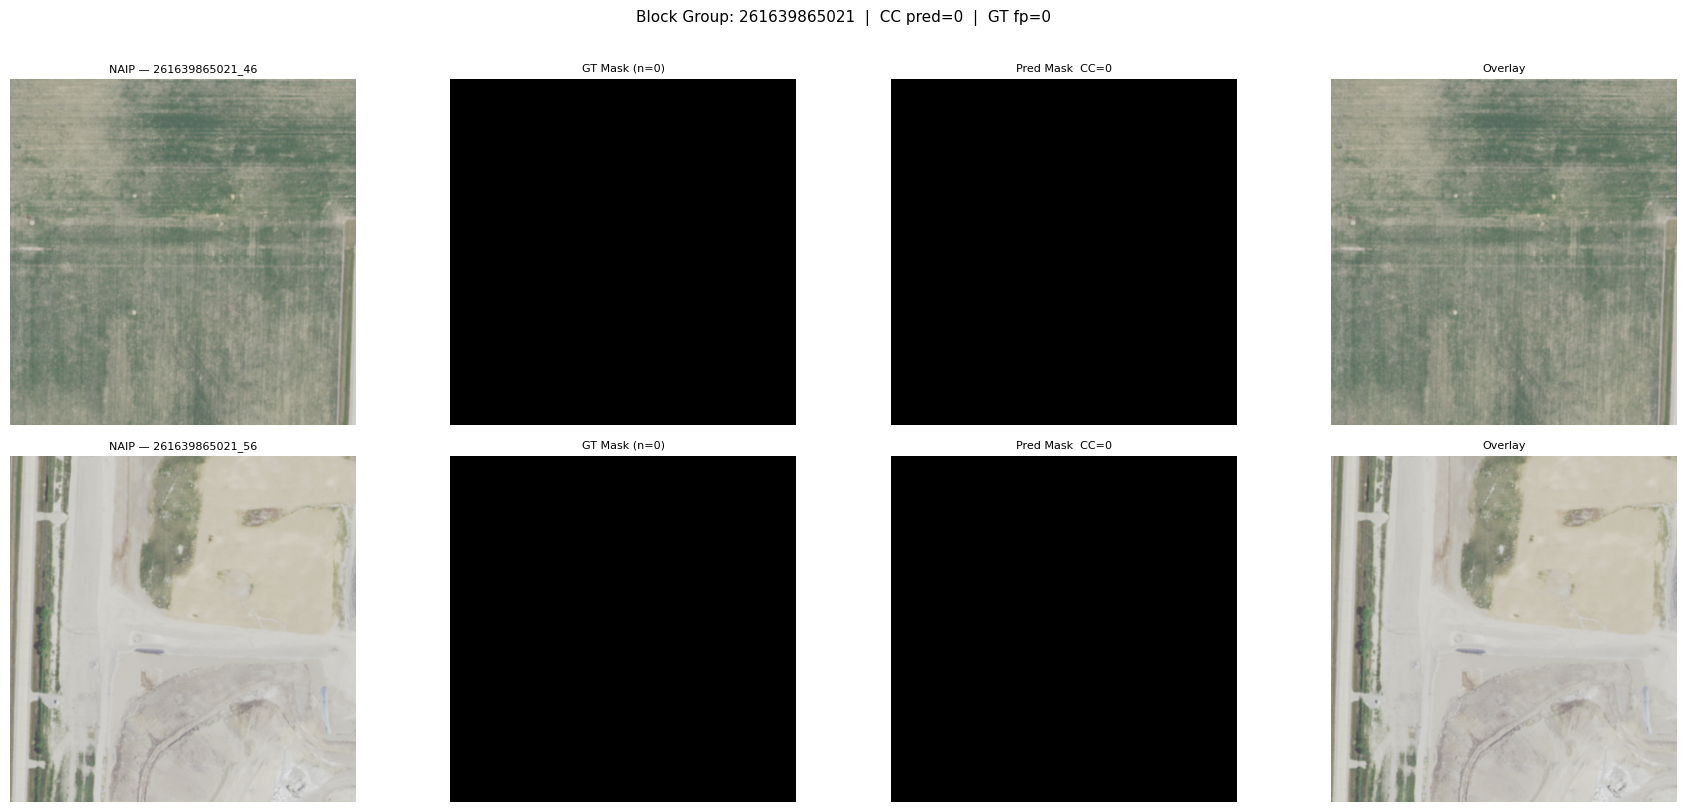

In [ ]:
def inspect_block_group(geoid=None, mode='worst', n_tiles=8):
    if geoid is None:
        df_sorted = df_valid.copy()
        df_sorted['abs_err'] = np.abs(df_sorted['pred_cc_count'] - df_sorted['acs_housing_units'])
        if mode == 'worst':
            geoid = df_sorted.sort_values('abs_err', ascending=False).iloc[0]['geoid']
        elif mode == 'best':
            geoid = df_sorted.sort_values('abs_err', ascending=True).iloc[0]['geoid']
        else:
            geoid = df_sorted.sample(1)['geoid'].values[0]

    bg_tiles = df_results[df_results['geoid'] == geoid].copy()
    if len(bg_tiles) == 0:
        print(f'No tiles found for GEOID: {geoid}'); return

    row     = df_valid[df_valid['geoid'] == geoid]
    acs_val = float(row['acs_housing_units'].values[0]) if len(row) > 0 else None
    pred_cc = float(bg_tiles['cc_count'].sum())
    gt_fp   = float(bg_tiles['gt_count'].sum())

    print(f'Block Group : {geoid}')
    print(f'Tiles       : {len(bg_tiles)}')
    print(f'GT Footprints (sum) : {gt_fp:.0f}')
    print(f'Pred CC count (sum) : {pred_cc:.0f}')
    if acs_val:
        print(f'DHC housing units   : {acs_val:.0f}')
        print(f'CC error vs DHC     : {abs(pred_cc - acs_val):.1f}')

    show_tiles = bg_tiles.head(n_tiles)
    n_show     = len(show_tiles)
    fig, axes  = plt.subplots(n_show, 4, figsize=(18, 4 * n_show))
    if n_show == 1: axes = axes[np.newaxis, :]

    model.eval()
    for i, (_, tile_row) in enumerate(show_tiles.iterrows()):
        tid    = tile_row['tile_id']
        gt_cnt = int(tile_row['gt_count'])
        cc_cnt = int(tile_row['cc_count'])

        img_np  = np.array(Image.open(f'{TILE_IMG_DIR}/{tid}.png').convert('RGB'))
        mask_np = np.array(Image.open(f'{TILE_MASK_DIR}/{tid}.png').convert('L'))

        aug   = val_aug(image=img_np)
        img_t = aug['image'].unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            seg_logit = model(img_t)
        pred_mask = (torch.sigmoid(seg_logit[0, 0]) > BEST_THRESHOLD).cpu().numpy()

        overlay = img_np.copy()
        overlay[pred_mask] = (overlay[pred_mask] * 0.5 + np.array([255, 50, 50]) * 0.5).astype(np.uint8)

        axes[i][0].imshow(img_np);                     axes[i][0].set_title(f'NAIP — {tid}', fontsize=8)
        axes[i][1].imshow(mask_np > 127, cmap='gray'); axes[i][1].set_title(f'GT Mask (n={gt_cnt})', fontsize=8)
        axes[i][2].imshow(pred_mask, cmap='gray');     axes[i][2].set_title(f'Pred Mask  CC={cc_cnt}', fontsize=8)
        axes[i][3].imshow(overlay);                    axes[i][3].set_title('Overlay', fontsize=8)
        for ax in axes[i]: ax.axis('off')

    title = f'Block Group: {geoid}  |  CC pred={pred_cc:.0f}  |  GT fp={gt_fp:.0f}'
    if acs_val: title += f'  |  DHC={acs_val:.0f}'
    plt.suptitle(title, fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/inspector_{geoid}.png', dpi=120, bbox_inches='tight')
    plt.show()


print('=== WORST block group ===')
inspect_block_group(mode='worst')

print('\n=== BEST block group ===')
inspect_block_group(mode='best')


---
# Phase 5-5: Experiment Log

In [ ]:
log_path = f'{BASE_DIR}/results/experiment_log.csv'
os.makedirs(f'{BASE_DIR}/results', exist_ok=True)

log_rows = [{
    'phase'          : 'phase5_final_dhc',
    'model'          : 'Seg-Only U-Net (CC)',
    'sampling'       : 'full_curated_7462',
    'threshold'      : BEST_THRESHOLD,
    'min_area'       : BEST_MIN_AREA,
    'n_block_groups' : len(df_valid),
    'cc_mae_vs_dhc'  : round(mae_cc,  2),
    'gt_mae_vs_dhc'  : round(mae_gt,  2),
    'cc_corr_vs_dhc' : round(corr_cc, 4),
    'gt_corr_vs_dhc' : round(corr_gt, 4),
    'checkpoint'     : BEST_CKPT,
}]

new_df = pd.DataFrame(log_rows)
if os.path.exists(log_path):
    new_df = pd.concat([pd.read_csv(log_path), new_df], ignore_index=True)
new_df.to_csv(log_path, index=False)

print('=' * 60)
print('  PHASE 5 (DHC) — FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'  Block groups evaluated : {len(df_valid)}')
print(f'  CC  MAE vs DHC         : {mae_cc:.2f}')
print(f'  GT  MAE vs DHC (ref)   : {mae_gt:.2f}')
print(f'  CC  Pearson r vs DHC   : {corr_cc:.4f}')
print(f'  GT  Pearson r vs DHC   : {corr_gt:.4f}')
print('=' * 60)
print('Experiment log updated.')


  PHASE 5 (DHC) — FINAL RESULTS SUMMARY
  Block groups evaluated : 1267
  CC  MAE vs DHC         : 513.84
  GT  MAE vs DHC (ref)   : 512.80
  CC  Pearson r vs DHC   : 0.1559
  GT  Pearson r vs DHC   : 0.1072
Experiment log updated.


## Results Note


MAE ~513 and Pearson r ~0.16 for both CC and MS Footprints vs Census DHC.
The low correlation is not a model failure — it reflects a fundamentalmismatch between building count (0–251 per block group) and housing units(0–2145), since a single building can contain hundreds of units (e.g. apartments). MS Footprints (ground truth) shows the same low correlation (r=0.107),confirming this is a data scale issue, not a segmentation issue.


Next step: filter to single-family housing areas and re-evaluate.

In [ ]:
#CC vs MS Footprints correlation
cc_fp  = df_valid['pred_cc_count'].values
gt_fp  = df_valid['gt_fp_count'].values

mae_cc_fp  = np.abs(cc_fp - gt_fp).mean()
corr_cc_fp = np.corrcoef(cc_fp, gt_fp)[0, 1]

print('=' * 54)
print(f'  CC (seg-only) vs MS Footprints')
print('=' * 54)
print(f'  MAE       : {mae_cc_fp:.2f}')
print(f'  Pearson r : {corr_cc_fp:.4f}')
print('=' * 54)

  CC (seg-only) vs MS Footprints
  MAE       : 7.30
  Pearson r : 0.9375


| Comparison | MAE | Pearson r | Note |
|---|---|---|---|
| CC vs MS Footprints (val set) | 1.54 | 0.957 | 1,493 tiles |
| CC vs MS Footprints (all tiles) | 7.30 | 0.9375 | 7,462 tiles |
| CC vs ACS / DHC (block group) | ~513 | ~0.16 | Scale mismatch — building count ≠ housing units |

Across all 7,462 tiles, CC-derived building counts achieve MAE of 7.30 and Pearson r of 0.9375 against Microsoft Building Footprints, confirming strong model performance at the tile level. The disconnect with ACS/DHC (r~0.16) reflects the fundamental difference between building count and housing unit measures.